In [ ]:
from pathlib import Path
import json

from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine
from scipy.stats import skew, skewtest, kurtosis, kurtosistest
from sklearn.metrics.pairwise import cosine_similarity

from lib.pose_utils import get_poem_embedding
from mime_db import MimeDb

# Connect to the database
db = await MimeDb.create()

In [ ]:
# This cell is just to explore the data available for one video -- usually skipped

VIDEO_FILE = "A_Letter_to_My_Nephew.mp4"  # Just the name of the video file, no path

video_path = Path("videos", VIDEO_FILE)

# Get video metadata
video_name = video_path.name
print(video_name)
video_id = await db.get_video_id(video_name)

print("VIDEO ID", video_id)

video_data = await db.get_video_by_id(video_id)
video_fps = video_data["fps"]
video_frame_count = video_data["frame_count"]

video_seconds = video_frame_count / video_fps

video_poses = await db.get_pose_data_from_video(video_id)
video_hands = await db.get_hand_data_from_video(video_id)

A_Letter_to_My_Nephew.mp4
VIDEO ID 62534624-4e59-11f0-905d-0b80be28ccce


In [14]:
def get_distribution_stats(distrib, plot=False):

    if len(distrib) == 0:
        return {
            "count": 0,
            "mean": 0,
            "median": 0,
            "stdev": 0,
            "skewness": 0,
            "kurtosis": 0,
        }

    if skewtest(distrib).pvalue < 0.05:
        skewness = skew(distrib)
    else:
        skewness = 0

    if kurtosistest(distrib).pvalue < 0.05:
        kurtosis_value = kurtosis(distrib)
    else:
        kurtosis_value = 0

    if plot:
        plt.hist(distrib, bins="auto")  # arguments are passed to np.histogram
        plt.show()

    return {
        "count": len(distrib),
        "mean": np.mean(distrib),
        "median": np.median(distrib),
        "stdev": np.std(distrib),
        "skewness": skewness,
        "kurtosis": kurtosis_value,
    }


stylometry_videos = [
    "A_Letter_to_My_Nephew.mp4",
    "Analogy-Dora_Tramontane.mp4",
    "A_Quarelling_Pair-2007_upscaled.mp4",
    "BillTJones_Analogy_Ambros_The_Emigrant.mp4",
    "D-ManintheWaters.mp4",
    "FondlyDoWeHope-Fervently_Do_We_Pray.mp4",
    "Holzer_DuetTruisms_upscaled.mp4",
    "PlayandPlay.mp4",
    "Secret_Pastures.mp4",
    "Story-Time.mp4",
    "WeShallNotBeMoved_upscaled.mp4",
    "A_Balsa_da_Medusa-oratorio_de_Hans_Werner_Henze_Opera_Holandesa.mp4",
    "Democracy_in_America_upscaled.mp4",
    "Don_Giovanni_Mozart.mp4",
    "Go_Down_Moses_2014.mp4",
    "Inferno_Dante.mp4",
    "Parsifal-Wagner-La_Monnaie-De_Munt.mp4",
    "Purgatorio-Dante_upscaled.mp4",
    "Requiem-Mozart-Festival_dAix-en-Provence.mp4",
    "Resurrection-Mahler.mp4",
    "The_Magic_Flute_Mozart_La_Monnaie_De_Munt.mp4",
    "Bluebeard_Voix_Humaine.mp4",
    "Die_Gezeichneten.mp4",
    "Elektra_Strauss.mp4",
    "Ifigenia_emTauris-Gluck.mp4",
    "Lady_Macbeth_of_Mtsensk_Districtp1.mp4",
    "Lady_Macbeth_of_Mtsensk_Districtp2.mp4",
    "Medeia-Luigi_Cherubini.mp4",
    "Tales_of_Hoffman.mp4",
    "the_french.mp4",
    "Wozzeck_Alban_Berg.mp4",
]

director_videos = {}
video_directors = {}
director_videos["BillTJones"] = [
    "A_Letter_to_My_Nephew.mp4",
    "Analogy-Dora_Tramontane.mp4",
    "A_Quarelling_Pair-2007_upscaled.mp4",
    "BillTJones_Analogy_Ambros_The_Emigrant.mp4",
    "D-ManintheWaters.mp4",
    "FondlyDoWeHope-Fervently_Do_We_Pray.mp4",
    "Holzer_DuetTruisms_upscaled.mp4",
    "PlayandPlay.mp4",
    "Secret_Pastures.mp4",
    "Story-Time.mp4",
    "WeShallNotBeMoved_upscaled.mp4",
]
director_videos["Castellucci"] = [
    "A_Balsa_da_Medusa-oratorio_de_Hans_Werner_Henze_Opera_Holandesa.mp4",
    "Democracy_in_America_upscaled.mp4",
    "Don_Giovanni_Mozart.mp4",
    "Go_Down_Moses_2014.mp4",
    "Inferno_Dante.mp4",
    "Parsifal-Wagner-La_Monnaie-De_Munt.mp4",
    "Purgatorio-Dante_upscaled.mp4",
    "Requiem-Mozart-Festival_dAix-en-Provence.mp4",
    "Resurrection-Mahler.mp4",
    "The_Magic_Flute_Mozart_La_Monnaie_De_Munt.mp4",
]
director_videos["Warlikowski"] = [
    "Bluebeard_Voix_Humaine.mp4",
    "Die_Gezeichneten.mp4",
    "Elektra_Strauss.mp4",
    "Ifigenia_emTauris-Gluck.mp4",
    "Lady_Macbeth_of_Mtsensk_Districtp1.mp4",
    "Lady_Macbeth_of_Mtsensk_Districtp2.mp4",
    "Medeia-Luigi_Cherubini.mp4",
    "Tales_of_Hoffman.mp4",
    "the_french.mp4",
    "Wozzeck_Alban_Berg.mp4",
]
director_videos["Other"] = []
director_ids = {"BillTJones": 0, "Castellucci": 1, "Warlikowski": 2}
stylometry_directors = ["BillTJones", "Castellucci", "Warlikowski"]

for director in director_videos:
    for video_name in director_videos[director]:
        video_directors[video_name] = director_ids[director]

video_labels = [video_directors[video_name] for video_name in stylometry_videos]

with open("lib/pose_archetypes.json", "r") as poses_file:
    pose_archetypes = json.load(poses_file)
with open("lib/hand_archetypes.json", "r") as hands_file:
    hand_archetypes = json.load(hands_file)

pose_descriptions = [arch["description"] for arch in pose_archetypes] # [:10] # Only use 3x3 + 1 poses

hand_descriptions = [arch["description"] for arch in hand_archetypes]


In [ ]:
# Get the prevalence of a pose archetype in a video
# Given a pose archetype
# For every pose in the video
#   Calculate its cosine similarity to the archetype, put it into an array
# Average the similarities (maybe derive some other statistics too)
def get_fingerprints(archetypes, video_poses_or_hands, comparison_metric):
    mean_sims = []
    median_sims = []
    for archetype in archetypes: # [:10]
        sims = []
        if comparison_metric == "poem_embedding":
            flattened_global3d = [c for i, c in enumerate(archetype["global3d_coco13"]) if (i + 1) % 3 != 0]
            archetype_vector = get_poem_embedding(flattened_global3d)
        else:
            archetype_vector = archetype[comparison_metric]
        for pose_or_hand in video_poses_or_hands:
            sims.append(cosine(archetype_vector, pose_or_hand[comparison_metric]))

        mean_sims.append(np.mean(sims))
        median_sims.append(np.median(sims))

    return {"mean": mean_sims, "median": median_sims}

delsarte_pose_fingerprints = {}
for video_name in stylometry_videos:
    print("Computing pose fingerprints for", video_name)
    video_id = await db.get_video_id(video_name)
    video_poses = await db.get_pose_data_from_video(video_id)
    delsarte_pose_fingerprints[video_name] = {"poem_embedding": get_fingerprints(pose_archetypes, video_poses, "poem_embedding"), "global3d_coco13": get_fingerprints(pose_archetypes, video_poses, "global3d_coco13")}

delsarte_hand_fingerprints = {}
for video_name in stylometry_videos:
    print("Computing hand fingerprints for", video_name)
    video_id = await db.get_video_id(video_name)
    video_hands = await db.get_hand_data_from_video(video_id)
    delsarte_hand_fingerprints[video_name] = {"joint_angles3d": get_fingerprints(hand_archetypes, video_hands, "joint_angles3d"), "class_weights": get_fingerprints(hand_archetypes, video_hands, "class_weights")}

Computing hand fingerprints for A_Letter_to_My_Nephew.mp4
Computing hand fingerprints for Analogy-Dora_Tramontane.mp4
Computing hand fingerprints for A_Quarelling_Pair-2007_upscaled.mp4
Computing hand fingerprints for BillTJones_Analogy_Ambros_The_Emigrant.mp4
Computing hand fingerprints for D-ManintheWaters.mp4
Computing hand fingerprints for FondlyDoWeHope-Fervently_Do_We_Pray.mp4
Computing hand fingerprints for Holzer_DuetTruisms_upscaled.mp4
Computing hand fingerprints for PlayandPlay.mp4
Computing hand fingerprints for Secret_Pastures.mp4
Computing hand fingerprints for Story-Time.mp4
Computing hand fingerprints for WeShallNotBeMoved_upscaled.mp4
Computing hand fingerprints for A_Balsa_da_Medusa-oratorio_de_Hans_Werner_Henze_Opera_Holandesa.mp4
Computing hand fingerprints for Democracy_in_America_upscaled.mp4
Computing hand fingerprints for Don_Giovanni_Mozart.mp4
Computing hand fingerprints for Go_Down_Moses_2014.mp4
Computing hand fingerprints for Inferno_Dante.mp4
Computing han

In [ ]:
# This determines whether the cells below consider poses or hands
#delsarte_fingerprints = delsarte_pose_fingerprints
delsarte_fingerprints = delsarte_hand_fingerprints

A_Letter_to_My_Nephew.mp4 Prediction: 0 True: 0
Analogy-Dora_Tramontane.mp4 Prediction: 0 True: 0
A_Quarelling_Pair-2007_upscaled.mp4 Prediction: 2 True: 0
BillTJones_Analogy_Ambros_The_Emigrant.mp4 Prediction: 0 True: 0
D-ManintheWaters.mp4 Prediction: 2 True: 0
FondlyDoWeHope-Fervently_Do_We_Pray.mp4 Prediction: 0 True: 0
Holzer_DuetTruisms_upscaled.mp4 Prediction: 2 True: 0
PlayandPlay.mp4 Prediction: 0 True: 0
Secret_Pastures.mp4 Prediction: 0 True: 0
Story-Time.mp4 Prediction: 0 True: 0
WeShallNotBeMoved_upscaled.mp4 Prediction: 0 True: 0
A_Balsa_da_Medusa-oratorio_de_Hans_Werner_Henze_Opera_Holandesa.mp4 Prediction: 0 True: 1
Democracy_in_America_upscaled.mp4 Prediction: 0 True: 1
Don_Giovanni_Mozart.mp4 Prediction: 2 True: 1
Go_Down_Moses_2014.mp4 Prediction: 2 True: 1
Inferno_Dante.mp4 Prediction: 0 True: 1
Parsifal-Wagner-La_Monnaie-De_Munt.mp4 Prediction: 0 True: 1
Purgatorio-Dante_upscaled.mp4 Prediction: 2 True: 1
Requiem-Mozart-Festival_dAix-en-Provence.mp4 Prediction: 0 T

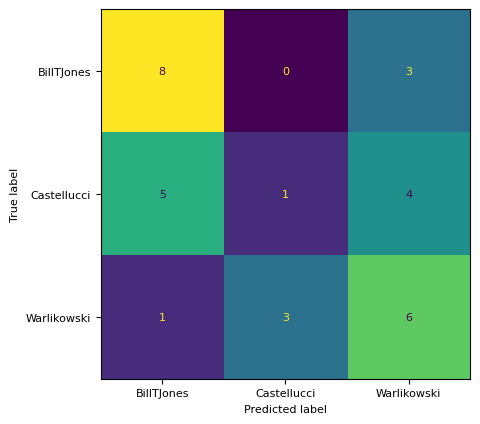

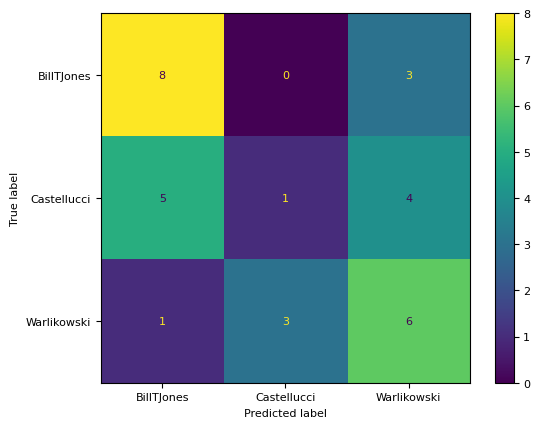

In [ ]:
# "Dumbest" possible classifier, using "leave one out" approach and cosine similarity

hits = 0
misses = 0

predictions = []

metric = "joint_angles3d" # either poem_embedding or global3d_coco13 for poses, or joint_angles3d or class_weights for hands
submetric = "mean" # either mean or median

for i, video_name in enumerate(stylometry_videos):

    fingerprints_by_director = {
        "BillTJones": [],
        "Castellucci": [],
        "Warlikowski": [],
    }

    for e, comparison_video in enumerate(stylometry_videos):
        if e == i:
            continue

        video_director = stylometry_directors[video_directors[comparison_video]]
        
        fingerprints_by_director[video_director].append(delsarte_fingerprints[comparison_video][metric][submetric])

    billtjones_avg_fingerprint = np.mean(
        fingerprints_by_director["BillTJones"], axis=0
    )
    castellucci_avg_fingerprint = np.mean(
        fingerprints_by_director["Castellucci"], axis=0
    )
    warlikowski_avg_fingerprint = np.mean(
        fingerprints_by_director["Warlikowski"], axis=0
    )

    directors_matrix = np.stack(
        (
            billtjones_avg_fingerprint,
            castellucci_avg_fingerprint,
            warlikowski_avg_fingerprint,
        ),
        axis=0,
    )

    video_fingerprint = delsarte_fingerprints[video_name][metric][submetric]
    true_label = video_directors[video_name]

    sims = cosine_similarity(directors_matrix, np.array([video_fingerprint]))

    pred_label = np.argmax(sims)
    print(video_name, "Prediction:", pred_label, "True:", true_label)

    predictions.append(pred_label)

    if pred_label == true_label:
        hits += 1
    else:
        misses += 1

print("Hits:", hits, "Misses:", misses, f"{hits*100/(hits+misses):.2f}%")

confusion_matrix = metrics.confusion_matrix(video_labels, predictions)
cm_display = metrics.ConfusionMatrixDisplay.from_predictions(
    video_labels,
    predictions,
    display_labels=["BillTJones", "Castellucci", "Warlikowski"],
    colorbar=False,
)
cm_display.plot()
plt.show()

Hits: 176, Misses: 134, 56.77%


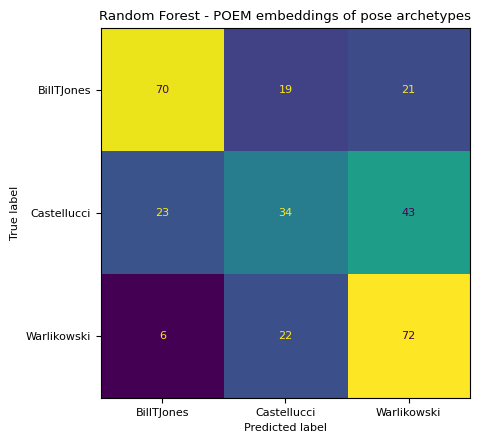

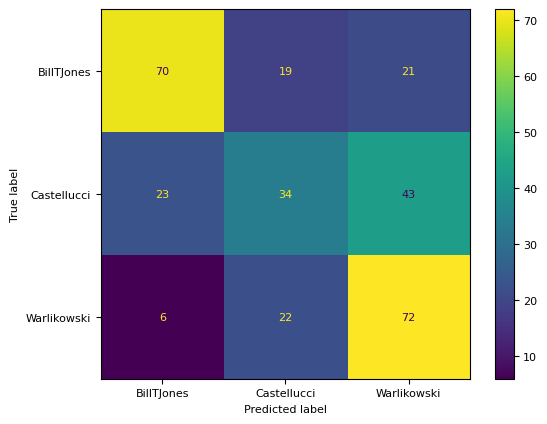

In [ ]:
# Train a classifier on all but one; see where that one is classified,
# repeat for all videos (leave-one-out).
# Potentially repeat the process for different random seeds, if the
# classification algorithm is nondeterministic

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# import xgboost as xgb
# from sklearn.svm import SVC, LinearSVC, NuSVC
# from sklearn.neural_network import MLPClassifier

N_SEEDS = 10

hits = 0
misses = 0
predicted = []
actual = []

metric = "joint_angles3d" # either poem_embedding or global3d_coco13 for poses, or joint_angles3d or class_weights for hands
submetric = "median" # either mean or median

X = []
for video_name in stylometry_videos:
    X.append(delsarte_fingerprints[video_name][metric][submetric])

for r in range(N_SEEDS):
    for h, held_out_vector in enumerate(X):

        X_train = np.delete(X, h, 0)
        y_train = np.delete(video_labels, h, 0)
        # X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.33, random_state=r)

        # clf = MLPClassifier()
        # clf = NuSVC(random_state=42)
        # clf = GaussianNB()
        # clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2)
        clf = RandomForestClassifier(random_state=r)
        clf.fit(X_train, y_train)
        # clf.fit(X_train,  y_train, eval_set=[(X_test, y_test)])

        # pred = clf.predict(held_out_vector.reshape(1, -1))[0]
        pred = clf.predict([held_out_vector])[0]

        if pred == video_labels[h]:
            hits += 1
        else:
            misses += 1

        actual.append(video_labels[h])
        predicted.append(pred)

        # print("For ", video_names[h], "pred is", pred, "true is", video_labels[h])

print(f"Hits: {hits}, Misses: {misses}, {hits*100/(hits+misses):.2f}%")

confusion_matrix = metrics.confusion_matrix(actual, predicted)
cm_display = metrics.ConfusionMatrixDisplay.from_predictions(
    actual,
    predicted,
    display_labels=["BillTJones", "Castellucci", "Warlikowski"],
    colorbar=False,
)
plt.title("Random Forest - POEM embeddings of pose archetypes")
cm_display.plot()

In [47]:
from sklearn.model_selection import cross_validate, cross_val_score, KFold
import random
from datetime import datetime

# Another way to do it
# scoring = ['precision_macro', 'recall_macro']
# clf = RandomForestClassifier(random_state=0)
# scores = cross_validate(clf, video_feat_matrix, video_labels, scoring=scoring)
# print("precision scores:", scores["test_precision_macro"], "recall scores:", scores["test_recall_macro"])

metric = "class_weights" # either poem_embedding or global3d_coco13 for poses, or joint_angles3d or class_weights for hands
submetric = "median" # either mean or median

X = []
for video_name in stylometry_videos:
    X.append(delsarte_fingerprints[video_name][metric][submetric])

N_SEEDS = 10

print("10-fold cross validation with 10 random seeds for video feature vectors")
all_scores = []
for i in range(N_SEEDS):
    r = random.seed(datetime.now().timestamp())
    # clf = RandomForestClassifier(random_state=r)
    clf = GaussianNB()
    cv = KFold(n_splits=10, random_state=r)
    scores = cross_val_score(
        clf, X, video_labels, scoring="accuracy", cv=cv, n_jobs=-1
    )
    all_scores.extend(scores)
print(
    "Accuracy: %.3f ,\nStandard Deviations :%.3f"
    % (np.mean(all_scores), np.std(all_scores))
)

10-fold cross validation with 10 random seeds for video feature vectors
Accuracy: 0.475 ,
Standard Deviations :0.312


Elapsed time to compute the importances: 0.026 seconds


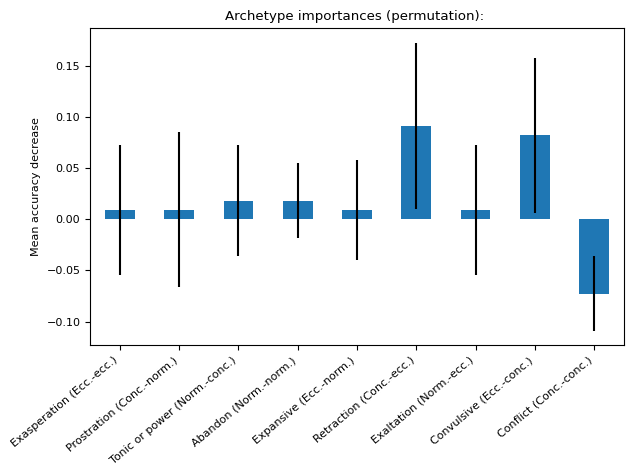

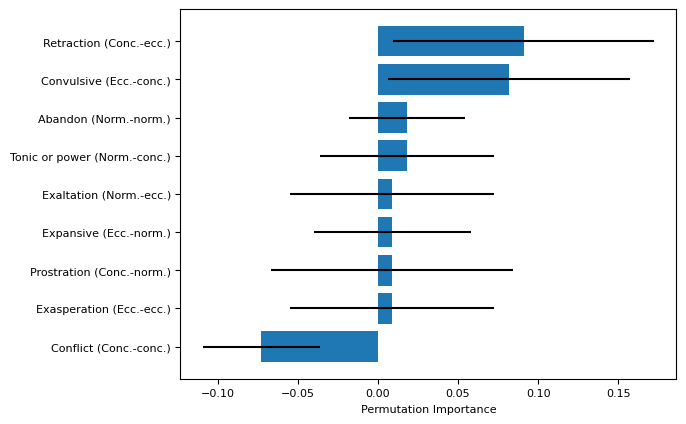

In [41]:
from sklearn.inspection import permutation_importance
import time

feature_names = hand_descriptions # or pose_descriptions

metric = "class_weights" # either poem_embedding or global3d_coco13 for poses, or joint_angles3d or class_weights for hands
submetric = "mean" # either mean or median

X = []
for video_name in stylometry_videos:
    X.append(delsarte_fingerprints[video_name][metric][submetric])

# import xgboost as xgb

# X_train, X_test, y_train, y_test = train_test_split(
#     video_feat_matrix, video_labels, test_size=0.33, random_state=42
# )
# X_train, X_test, y_train, y_test = train_test_split(video_mean_poem_embeddings, video_labels, test_size=0.33, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, video_labels, test_size=0.33, random_state=42
)

# clf = RandomForestClassifier(random_state=0)
clf = GaussianNB()
# clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2)

clf.fit(X_train, y_train)
# clf.fit(X_train, y_train, eval_set=[(X_test, y_test)])

start_time = time.time()
perm_importance = permutation_importance(
    clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
elapsed_time = time.time() - start_time
print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

clf_importances = pd.Series(perm_importance.importances_mean, index=feature_names)

# importances = clf.feature_importances_
# importances_std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)
# clf_importances = pd.Series(importances, index=vector_names)

fig, ax = plt.subplots()
clf_importances.plot.bar(yerr=perm_importance.importances_std, ax=ax)
ax.set_title("Archetype importances (permutation): ")
ax.set_ylabel("Mean accuracy decrease")
ax.tick_params(axis="x", labelrotation=40)
plt.setp(ax.xaxis.get_majorticklabels(), ha="right")
fig.tight_layout()
plt.show()

sorted_idx = perm_importance.importances_mean.argsort()

# plt.barh(
#     np.array(feature_names)[sorted_idx],
#     perm_importance.importances_mean[sorted_idx],
#     xerr=perm_importance.importances_std[sorted_idx],
# )
# plt.barh(np.array(vector_names)[sorted_idx], perm_importance.importances_mean[sorted_idx], xerr=perm_importance.importances_std[sorted_idx])
plt.barh(
    np.array(feature_names)[sorted_idx],
    perm_importance.importances_mean[sorted_idx],
    xerr=perm_importance.importances_std[sorted_idx],
)
plt.xlabel("Permutation Importance")
plt.show()